<a href="https://colab.research.google.com/github/yabaroah/Sprint-7_ConnectaTel_Analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
print ('Plans:')
print(plans.info())

Plans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
None


In [ ]:
# inspección de users con .info()
print ('Users:')
print(users.info())

Users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None


In [ ]:
# inspección de usage con .info()
print ('Usage:')
print(usage.info())

Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('Valores nulos en users:')
print(users.isna().sum())# Cantidad de valores nulos)
print('Proporción de datos ausentes en users:')
print(users.isna().mean() * 100) # Proporción de valores nulos)
users["city"].value_counts(dropna=False)

Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de datos ausentes en users:
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
# cantidad de nulos para usage
print('Valores nulos en usage:')
print(usage.isna().sum())# Cantidad de valores nulos)
print('Proporción de datos ausentes en usage:')
print(usage.isna().mean() * 100) # Proporción de valores nulos)
usage.isna().any()


Valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de datos ausentes en usage:
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


id          False
user_id     False
type        False
date         True
duration     True
length       True
dtype: bool

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
-
- En 'users', encontramos dos columnas con datos faltantes:
- 'city' con 11.7% de datos faltantes.
- 'churn_date' con 88.3% de datos faltantes.
-
- En 'usage', también hay dos columnas con datos faltantes:
- 'duration' con 55.19% de datos faltantes
- 'length' con 44.74% de datos faltantes
- 'date', con 0.125% de datos faltantes
-
- Indica qué harías: ¿imputar, eliminar, ignorar?
-
- En 'users':
- Para 'city', MCAR, explorar a qué se deben estos faltantes, posteriormente decidir su tratamiento.
- Para 'churn_date', MNAR, explorar, el porcentaje es demasiado alto por lo que la recomendación es eliminarlo.
-
- En 'usage':
- 'duration' y 'length', MAR, están relacionadas con 'type' ('call' o 'text'), son complementarias, sí dan información por lo que hay que explorar más antes de manipular los datos.
- 'date', MCAR, imputar o dejar como nulo


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print('Resumen estadístico de users')
print(users.describe())

Resumen estadístico de users
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


In [ ]:
# cuenta user_id totales y ver si hay duplicados
total_registros = len(users)
id_unicos = users['user_id'].nunique()

print(f"Total de registros: {total_registros}")
print(f"IDs únicos: {id_unicos}")
print(f"¿Hay duplicados? {total_registros != id_unicos}")


Total de registros: 4000
IDs únicos: 4000
¿Hay duplicados? False


In [ ]:
# verifica cuántas edades menores a 18 hay registradas
print("Valores nulos:", users['age'].isnull().sum())
edades_imposibles = users[users['age'] <18]
print(f"Registros con edades negativas: {len(edades_imposibles)}")
#users[edades_imposibles].value_counts(dropna=False)


Valores nulos: 0
Registros con edades negativas: 55


In [ ]:
# identificar si son sentinels o inválidos
print("Valores únicos de edades imposibles:")
print(edades_imposibles['age'].value_counts().sort_index())

Valores únicos de edades imposibles:
-999    55
Name: age, dtype: int64


- La columna `user_id`,número único por registro, no hay duplicados
- La columna `age` tiene un rango con un límite inferior absurdo, lo que indica que hay al menos un dato que distorsiona los información estadística. Al explorar los datos, encontramos el sentinel -999 en 55 registros, no hay valores inválidos.

In [ ]:
# explorar columnas numéricas de usage
print('Resumen estadístico de usage')
print(usage.describe())

Resumen estadístico de usage
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


In [ ]:
# Contar id totales vs únicos para ver que no haya duplicados
total_registros = len(usage)
ids_unicos = usage['id'].nunique()

print(f"Total de registros: {total_registros}")
print(f"IDs únicos: {ids_unicos}")
print(f"¿Hay duplicados? {total_registros != ids_unicos}")

Total de registros: 40000
IDs únicos: 40000
¿Hay duplicados? False


In [ ]:
#explora las columnas duration y length
print(usage[['length', 'duration']].info())
print(usage[['length', 'duration']].head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   length    22104 non-null  float64
 1   duration  17924 non-null  float64
dtypes: float64(2)
memory usage: 625.1 KB
None
   length  duration
0     NaN      0.09
1    39.0       NaN
2    36.0       NaN
3     NaN      1.53
4     NaN      4.84
5     NaN      4.68
6     NaN      3.27
7     NaN      4.81
8    44.0       NaN
9    70.0       NaN


- Las columnas `id` y `user_id`son identificadores, por lo que el resumenr estadístico no brinda muchs información útil.
- Las columnas 'duration' y 'length' proporcionan información sobre los hábitos de uso, en llamadas y mensajes.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())
users["city"].value_counts(dropna=False)

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

- La columna `city` nos dice que hay 3531 entradas, 7 ciudades diferentes, la más común es Bogotá con 808 entradas. Tiene un signo de interrogación en 96 registros, hay que explorar y decidir tratamiento.
- La columna `plan` hay 4000 registros con dos planes distintos, siendo el 'Básico'el más común

In [ ]:
# explorar columna categórica de usage
print(usage['type'].describe())
usage["type"].value_counts(dropna=False)#muestra valores únicos en type, incluye valores NaN

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


text    22092
call    17908
Name: type, dtype: int64

In [ ]:
# muestra casos donde hay valores en 'length´y 'duration'
condicion = (usage['length'].notna()) & (usage['duration'].notna())
registros_con_ambos = usage[condicion]
print(f"Número de registros con ambas columnas: {len(registros_con_ambos)}")
print(registros_con_ambos[['length', 'duration','type']])

Número de registros con ambas columnas: 28
       length  duration  type
1414     65.0    120.00  text
1824     40.0    120.00  text
1932     69.0    120.00  text
2070   1490.0      1.68  call
2972     68.0    120.00  text
5272   1490.0      3.78  call
10614  1490.0      0.53  call
11456    23.0    120.00  text
12692  1490.0      1.80  call
16702    48.0    120.00  text
16910  1490.0      3.29  call
20727  1490.0      0.40  call
20778  1490.0      1.01  call
22814    70.0    120.00  text
23052    24.0    120.00  text
23451    53.0    120.00  text
25444  1490.0      3.57  call
26057  1490.0      0.63  call
26506  1490.0      1.12  call
26561    89.0    120.00  text
26587  1490.0      1.03  call
27171    44.0    120.00  text
28921    53.0    120.00  text
36587    27.0    120.00  text
37562    28.0    120.00  text
37981  1490.0      0.93  call
38954    47.0    120.00  text
39522    19.0    120.00  text


- La columna `type`tiene 4000 registros, con dos tipos diferentes de servicio, donde el más frecuentemente utilizado es 'text', con 22092 registros.
- Hay 28 registros que tienen información en duration y en length, que no deberían tener. Si son tipo 'call', no deberían tener 'length'. Si son tipo 'text', no deberían tener 'duration'hay que corregirlos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
en users:
'age', sentinel -999 en 55 registros
en usage:
'city' valor inválido '?' en 96 registros
'duration' sentinel '120' en 16 registros donde ese valor no debería estar, porque son registros 'text'
'length' sentinel '1490' en 12 registros  donde ese valor no debería estar, porque son registros 'call'
- ¿Qué acción tomarías?
- imputar en 'age'
- dejar como NaN en 'city', porque no se puede identificar el dato correcto
- imputar como NaN en'duration' y 'length' donde corresponda
  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# verifica el tipo de dato de 'reg_date' de users
users["reg_date"].dtype

dtype('O')

In [ ]:
# Convierte a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users["reg_date"], errors="coerce", utc=True)
print(users["reg_date"].dtype)
users.head()
# completa el código

datetime64[ns, UTC]


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619+00:00,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN


In [ ]:
# verifica el tipo de dato de 'date' de usage
usage["date"].dtype


dtype('O')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage["date"], errors="coerce", utc=True)
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00+00:00,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244+00:00,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488+00:00,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733+00:00,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977+00:00,4.84,NaN


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dtype)
print(users["reg_date"].isna().sum())
#genera una columna para el año 'year' y una para el mes 'month'
users["year"]  = users["reg_date"].dt.year
users["month"] = users["reg_date"].dt.month
# permite ver los años en los que hay registros y cuántos registros hay por año
print(users["year"].value_counts(dropna=False))

#muestra los registros con fecha futura (2026)

#users_2026 = users[users["year"] == 2026]
#print(users_2026)


datetime64[ns, UTC]
0
2024    1330
2023    1316
2022    1314
2026      40
Name: year, dtype: int64


En `reg_date`, ya los datos son tipo datetime64, no hay registros vacíos, pero hay 40 registros con la misma fecha 2026-05-10 que no deberían existir, son futuras.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dtype)
print(usage["date"].isna().sum())
#genera una columna para el año 'year' y una para el mes 'month'
usage["year"]  = usage["date"].dt.year
usage["month"] = usage["date"].dt.month
# permite ver los años en los que hay registros y cuántos registros hay por año
usage["year"].value_counts(dropna=False)

#muestra los registros con fechas inválidas
#filas_con_nan = usage[pd.isnull(usage["date"])]
#print("Filas con NaT en columna 'date':")
#print(filas_con_nan)

datetime64[ns, UTC]
50


2024.0    39950
NaN          50
Name: year, dtype: int64

En `date`, ya los datos son tipo datetime64, hay 50 registros NaN, todos los demás registros son de 2024.   

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- sí, en 'usres' 'reg_date' aparecen datos de 2026 (futuros)
- en 'usage' 'date' hay 50 registros NaN
- ¿Qué harías con ellas? como es un porcentaje bajo y no tiene relación con otros campos, los ignoraría.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
print(age_mediana)
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

47.0


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date, crear cloumna flag_fechas_furutas
users['flag_fechas_futuras']= 1
users.loc[users["reg_date"].dt.year == 2026, 'flag_fechas_futuras'] = pd.NA
#verificar la creación del flag
print('Tipo de dato en flag_fechas_futuras :',users["flag_fechas_futuras"].dtype)
print('Número de registros en flag_fechas_futuras:',users["flag_fechas_futuras"].isna().sum())
users['flag_fechas_futuras'].describe()


Tipo de dato en flag_fechas_futuras : object
Número de registros en flag_fechas_futuras: 40


count     3960
unique       1
top          1
freq      3960
Name: flag_fechas_futuras, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby("type")["duration"].count())
print('Valores no nulos en duration: ',usage['duration'].notna().sum() )#cuenta valores no nulos en 'duration'
print('Valores nulos en duration: ',usage['duration'].isna().sum() )#cuenta valores nulos en 'duration'

type
call    17908
text       16
Name: duration, dtype: int64
Valores no nulos en duration:  17924
Valores nulos en duration:  22076


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby("type")["length"].count())
print('Valores no nulos en length: ',usage['length'].notna().sum() )#cuenta valores no nulos en 'duration'
print('Valores nulos en length: ',usage['length'].isna().sum() )#cuenta valores nulos en 'duration'

type
call       12
text    22092
Name: length, dtype: int64
Valores no nulos en length:  22104
Valores nulos en length:  17896


In [ ]:
# realiza el cambio a nulo en 'duration'
usage.loc[(usage['duration'].notna()) &  (usage['length'].notna()) & (usage['type'] == 'text'), 'duration'] = pd.NA

# Verificar cambios
print(usage.groupby("type")["duration"].count())
print('Valores no nulos en duration: ',usage['duration'].notna().sum() )#cuenta valores no nulos en 'duration'
print('Valores nulos en duration: ',usage['duration'].isna().sum() )#cuenta valores nulos en 'duration'

type
call    17908
text        0
Name: duration, dtype: int64
Valores no nulos en duration:  17908
Valores nulos en duration:  22092


In [ ]:
# realiza el camibio a nulo en 'length'
usage.loc[(usage['duration'].notna()) &  (usage['length'].notna()) & (usage['type'] == 'call'), 'length'] = pd.NA

# Verificar cambios
print(usage.groupby("type")["length"].count())
print('Valores no nulos en length: ',usage['length'].notna().sum() )#cuenta valores no nulos en 'duration'
print('Valores nulos en length: ',usage['length'].isna().sum() )#cuenta valores nulos en 'duration'

type
call        0
text    22092
Name: length, dtype: int64
Valores no nulos en length:  22092
Valores nulos en length:  17908


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Había 28 registros con información en 'duration' y 'length', cuando sólo deberían tener información en uno o en otro.
Los datos de 'length' en el tipo de servicio 'call', fueron convertidos en nulos.
Los datos de 'duration' en el tipo de servicio 'text' fueron convertidos en nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby(['user_id','type'])\
    .agg({'is_text': 'sum','is_call': 'sum','duration': 'sum' })\
    .reset_index()

# observar resultado
usage_agg.head(3)

,user_id,type,is_text,is_call,duration
0,10000,call,0,3,23.70
1,10000,text,7,0,0.00
2,10001,call,0,10,33.18


In [ ]:
# Renombrar columnas
usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", \
                          "duration": "cant_minutos_llamada"}, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,type,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,call,0,3,23.70
1,10000,text,7,0,0.00
2,10001,call,0,10,33.18


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on=['user_id'], how='inner')
user_profile.head(5)

,user_id,type,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,year,month,flag_fechas_futuras
0,10000,call,0,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,1,1
1,10000,text,7,0,0.00,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,1,1
2,10001,call,0,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,1,1
3,10001,text,5,0,0.00,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,1,1
4,10002,call,0,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,1,1


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
print("Columnas en user_profile:")
print(user_profile.columns.tolist())
print('Resumen estadístico de user_profile')
user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada', 'age']].describe()

Columnas en user_profile:
['user_id', 'type', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'year', 'month', 'flag_fechas_futuras']
Resumen estadístico de user_profile


,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,7939.000000,7939.00000,7939.000000,7939.000000
mean,2.782718,2.25570,11.503325,48.115506
std,3.229802,2.70729,16.401637,17.691724
min,0.000000,0.00000,0.000000,18.000000
25%,0.000000,0.00000,0.000000,33.000000
50%,1.000000,0.00000,0.000000,47.000000
75%,5.000000,4.00000,19.825000,63.000000
max,17.000000,15.00000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.831843
Premium    35.168157
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

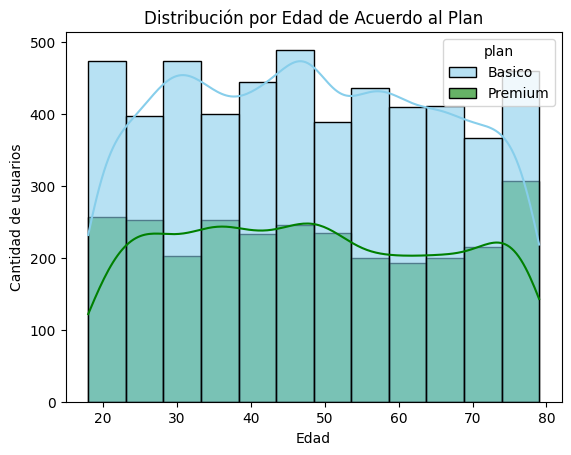

Media de edades por tipo de plas es :
               age
plan              
Basico   48.022149
Premium  48.287607

Mediana de edades por tipo de plas es :
          age
plan         
Basico   47.0
Premium  48.0


In [ ]:
# Histograma para visualizar la edad (age)


sns.histplot(
    data=user_profile,
    x='age',
    hue="plan",     # Variable categórica para diferenciar colores
    bins=12,         # Número de barras
    kde=True,        # Línea de densidad opcional
    palette=['skyblue','green'],  # Paleta de colores
    alpha=0.6        # Transparencia
)

plt.title("Distribución por Edad de Acuerdo al Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

print('Media de edades por tipo de plas es :')
print(user_profile[['plan','age']].groupby('plan').mean())
print()
print('Mediana de edades por tipo de plas es :')
print(user_profile[['plan','age']].groupby('plan').median())



Insights:
- Media y Mediana parecidos
- Las edades se ven distribuidas de manera bastante uniforme entre los 18 y los 80 años. No hay picos importantes, lo que sugiere una base de usuarios diversa en edad.
- El plan Básico tiene más usuarios en casi todos los rangos de edad.
- El plan Premium tiene menor cantidad de usuarios en todos los rangos y su distribución más   “plana”, sin grandes concentraciones.
- Domina el plan básico porque tiene más usuarios.
- La edad no segmenta fuertemente el tipo de plan.
- El segmento más valioso para estrategias es 30–50 años por tener mayor cantdad de usuarios.

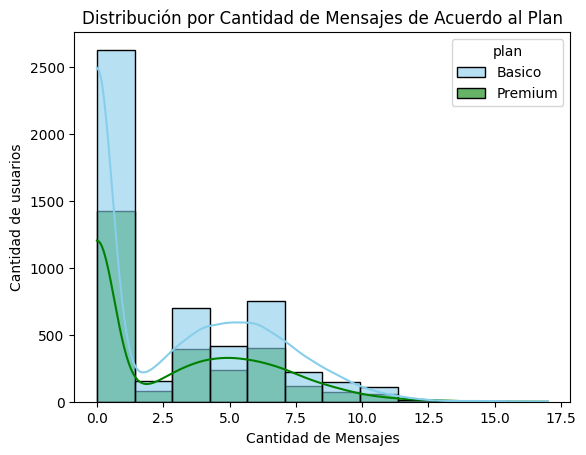


Media de la cantidad de mensajes por tipo de plan es :
         cant_mensajes
plan                  
Basico        2.785895
Premium       2.776862

Mediana  de la cantidad de mensajes por tipo de plan es:
         cant_mensajes
plan                  
Basico               1
Premium              1


In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue="plan",     # Variable categórica para diferenciar colores
    bins=12,         # Número de barras
    kde=True,        # Línea de densidad opcional
    palette=['skyblue','green'],  # Paleta de colores
    alpha=0.6        # Transparencia
)

plt.title("Distribución por Cantidad de Mensajes de Acuerdo al Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()
print()

print('Media de la cantidad de mensajes por tipo de plan es :')
print(user_profile[['plan','cant_mensajes']].groupby('plan').mean())
print()
print('Mediana  de la cantidad de mensajes por tipo de plan es:')
print(user_profile[['plan','cant_mensajes']].groupby('plan').median())


Insights:
- La mayoría de los usuarios casi no interactúan. El uso típico es 1 mensaje.
- Distribución sesgada a la derecha
- Hay una gran concentración en 0–1 mensajes (mediana), pero existen datos que llegan hasta 17 mensajes. Esto significa que hay muchos usuarios pasivos y un pequeño grupo de usuarios con mayor actividad.
- En el plan Básico hay mayor volumen total y más usuarios en el rango bajo (0–2 mensajes).
- En el plan Premium hay menor volumen total, pero los usuarios tienden a usar más el servicio.

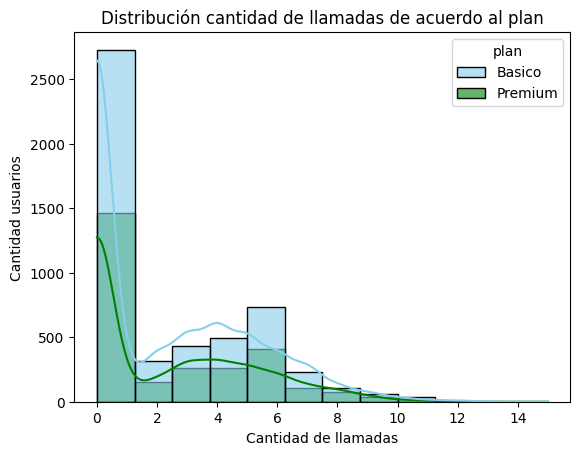

Media de la cantidad de llamadas por tipo de plan es :
         cant_llamadas
plan                  
Basico        2.245969
Premium       2.273639

Mediana  de la cantidad de llamadas por tipo de plan es:
         cant_llamadas
plan                  
Basico               0
Premium              0


In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue="plan",     # Variable categórica para diferenciar colores
    bins=12,         # Número de barras
    kde=True,        # Línea de densidad opcional
    palette=['skyblue','green'],  # Paleta de colores
    alpha=0.6        # Transparencia
)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad usuarios')
plt.title('Distribución cantidad de llamadas de acuerdo al plan')
plt.show()

print('Media de la cantidad de llamadas por tipo de plan es :')
print(user_profile[['plan','cant_llamadas']].groupby('plan').mean())
print()
print('Mediana  de la cantidad de llamadas por tipo de plan es:')
print(user_profile[['plan','cant_llamadas']].groupby('plan').median())

Insights:
Uso extremadamente bajo, 1 llamadas.La mayoría de usuarios no usa o casi no usa las llamadas.
Distribución sesgada a la derecha, algunos usuarios llegan hasta 10–15 llamadas, pero son pocos. La mayoría se queda en niveles muy bajos.
Hay un pequeño grupo de alto uso, pero no es masivo.
Básico:
Mayor volumen total.
Muchos usuarios con 0–2 llamadas.
Premium:
Menos usuarios más presentes en rangos 3–7 llamadas, pero no de forma contundente.

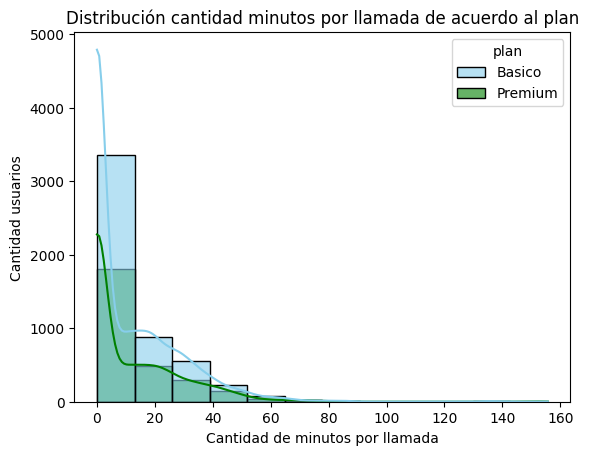

Media de la cantidad de minutos por llamada por tipo de plan es :
         cant_minutos_llamada
plan                         
Basico              11.380746
Premium             11.729298

Mediana  de la cantidad de minutos por llamada por tipo de plan es:
         cant_minutos_llamada
plan                         
Basico                    0.0
Premium                   0.0


In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue="plan",     # Variable categórica para diferenciar colores
    bins=12,         # Número de barras
    kde=True,        # Línea de densidad opcional
    palette=['skyblue','green'],  # Paleta de colores
    alpha=0.6        # Transparencia
)
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Cantidad usuarios')
plt.title('Distribución cantidad minutos por llamada de acuerdo al plan')
plt.show()

print('Media de la cantidad de minutos por llamada por tipo de plan es :')
print(user_profile[['plan','cant_minutos_llamada']].groupby('plan').mean())
print()
print('Mediana  de la cantidad de minutos por llamada por tipo de plan es:')
print(user_profile[['plan','cant_minutos_llamada']].groupby('plan').median())

💡Insights
Llamadas muy cortas dominan el comportamiento, hay un pico muy fuerte en los primeros minutos.
La mayoría de las llamadas están en el rango de 0 a 10 minuos.
La interacción principal por llamada es corto.
Distribución altamente sesgada a la derecha.
Existen llamadas largas (hasta ~150 minutos), pero son muy pocas.
Las llamadas largas son casos excepcionales, no el comportamiento estándar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

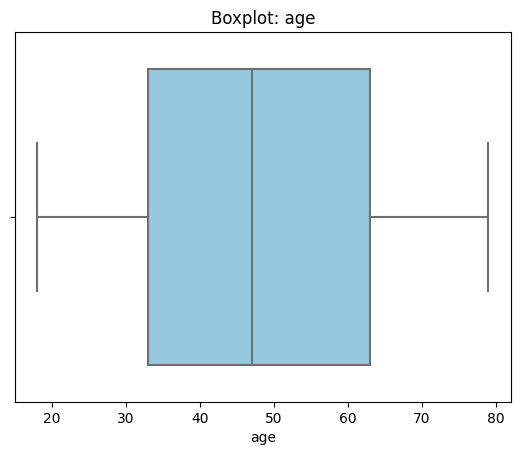

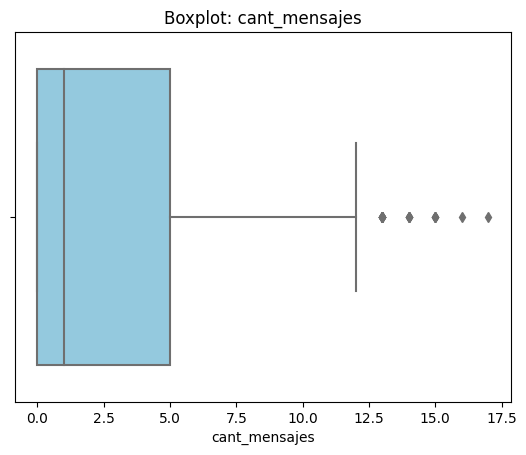

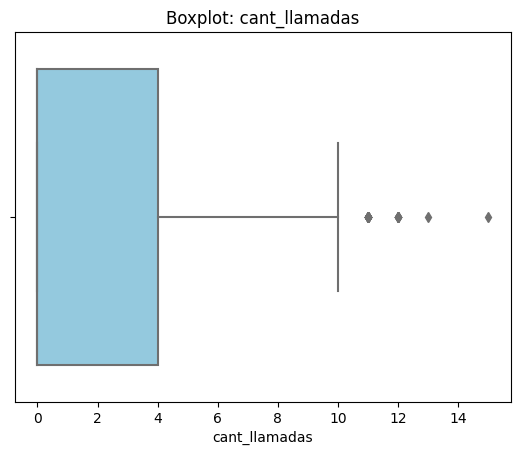

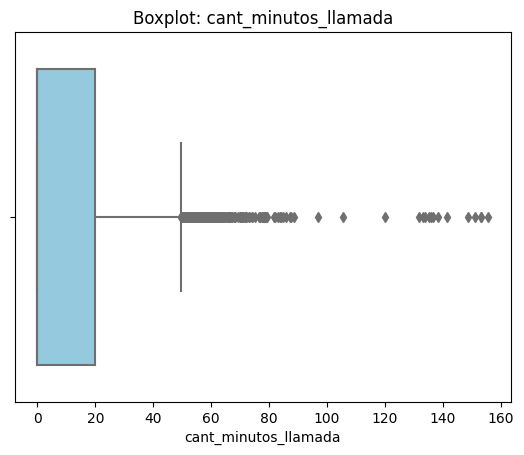

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta algunos outliers, hay que explorar e identificar
- cant_llamadas: presenta algunos outliers, hay que explorar e identificar
- cant_minutos_llamada: presenta muchos outliers, hay que explorar e identificar

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [ 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    print(col)
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil: ', Q1)

    #calcular Q3
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil: ', Q3)

    #calcular IQR
    IQR = Q3 - Q1
    print('IQR: ', IQR)

    #calcular límite inferior
    lower = Q1 - 1.5 * IQR
    print('Límite inferior: ', lower)

    #calcular límite superior
    upper = Q3 + 1.5 * IQR
    print('Límite superior: ', upper)



cant_mensajes
Primer cuartil:  0.0
Tercer cuartil:  5.0
IQR:  5.0
Límite inferior:  -7.5
Límite superior:  12.5
cant_llamadas
Primer cuartil:  0.0
Tercer cuartil:  4.0
IQR:  4.0
Límite inferior:  -6.0
Límite superior:  10.0
cant_minutos_llamada
Primer cuartil:  0.0
Tercer cuartil:  19.825000000000003
IQR:  19.825000000000003
Límite inferior:  -29.737500000000004
Límite superior:  49.56250000000001


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,7939.000000,7939.00000,7939.000000
mean,2.782718,2.25570,11.503325
std,3.229802,2.70729,16.401637
min,0.000000,0.00000,0.000000
25%,0.000000,0.00000,0.000000
50%,1.000000,0.00000,0.000000
75%,5.000000,4.00000,19.825000
max,17.000000,15.00000,155.690000


💡Insights:
- cant_mensajes: mantener outliers, por que representan datos reales de uso.
- cant_llamadas: mantener outliers porque son datos reales de uso y nos permiten ver los whales y enfocar algunas decisiones estratégicas del negocio
- cant_minutos_llamada: mantener, porque representan datos reales de uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),   # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]

# Definir los valores correspondientes
valores = ["Bajo uso", "Uso medio"]

# Crear la columna (el resto será "Alto uso" por defecto)
user_profile['grupo_uso'] = np.select(condiciones, valores, default="Alto uso")


In [ ]:
# verificar cambios
user_profile.head()

,user_id,type,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,year,month,flag_fechas_futuras,grupo_uso
0,10000,call,0,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,1,1,Bajo uso
1,10000,text,7,0,0.00,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,1,1,Uso medio
2,10001,call,0,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,1,1,Alto uso
3,10001,text,5,0,0.00,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,1,1,Uso medio
4,10002,call,0,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,1,1,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)  ]

# Definir los valores correspondientes
valores = ["Joven", "Adulto"]

# Crear la columna (el resto será "Alto uso" por defecto)
user_profile['grupo_edad'] = np.select(condiciones, valores, default= 'Adulto mayor')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,type,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,year,month,flag_fechas_futuras,grupo_uso,grupo_edad
0,10000,call,0,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,1,1,Bajo uso,Adulto
1,10000,text,7,0,0.00,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,1,1,Uso medio,Adulto
2,10001,call,0,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,1,1,Alto uso,Adulto
3,10001,text,5,0,0.00,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,1,1,Uso medio,Adulto
4,10002,call,0,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,1,1,Bajo uso,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

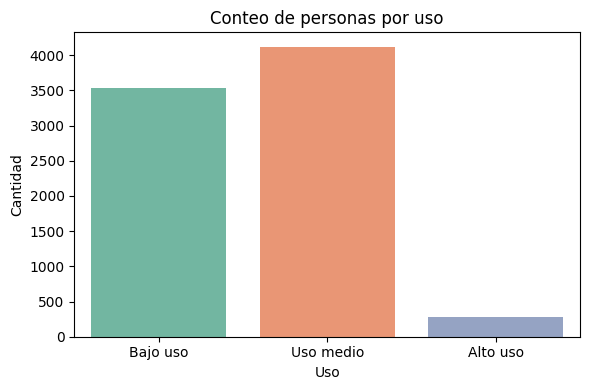

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6, 4))
sns.countplot(
        data=user_profile,
        x="grupo_uso",
        palette="Set2"
    )

# Personalizar
plt.title("Conteo de personas por uso")
plt.xlabel("Uso")
plt.ylabel("Cantidad")
plt.tight_layout()

# Mostrar gráfico
plt.show()

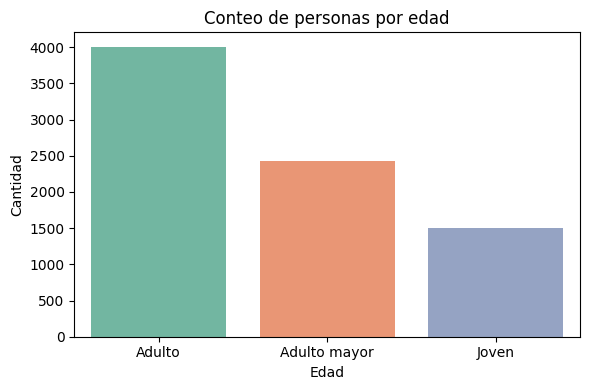

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6, 4))
sns.countplot(
        data=user_profile,
        x="grupo_edad",
        palette="Set2"
    )

# Personalizar
plt.title("Conteo de personas por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.tight_layout()

# Mostrar gráfico
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.


**Valores nulos e inválidos**  

En la base de datos 'users', se encontraron tres columnas con datos faltantes:

- 'city' con 11.7% de datos faltantes. Se encontró que en algunos casos se había utilizado el    valor sentinela '?'. La falta de datos se identificó como MACAR (missing completely at random). se sustituyó el sentinels por nulo.
  
- 'churn_date' con 88.3% de datos faltantes. La falta de datos se identificó como MNAR (missing  not at random). Se decidió eliminarla.

- 'age' se encontró un límite inferior absurdo, lo que indicó que al menos un dato que distorsionaba la información estadística. Al explorar los datos, encontramos el sentinel -999 en 55 registros, se imputó con la mediana para evitar distorsionar la información estadística.

- 'reg_date' con años futuros (2026) se marcaron, pero no se imputaron, por ser un porcentaje muy pequeño se ignoró.
  
En la base de datos 'usage', se encontraron tres columnas con datos faltantes:

- 'duration' con 55.19% de datos faltantes, y 'length' con 44.74% de datos faltantes. Estas columnas se identificó que los faltantes eran de tipo MAR (missing at random), los faltantes están relacionadas con el tipo de servicio. las llamadas 'call' solo deben tener duración 'duration' y los mensages ('messages') sólo longitud ('length'). Se identificaron 'falsos nulos', en 'length' se encontró el valor sentinela 1490 y en 'duration' el valor sentinela 120. En ambos casos los valores se imputaron como nulos.
  
- 'date', con 0.125% de datos faltantes de tipo MCAR. por ser un porcentaje muy pequeño se dejaron como nulos. Se estandarizaron las fechas.


🔍 **Segmentos por Edad**
- Distribución amplia uniforme y sin valores atípicos
- Mayor concentración en adultos
- La edad no segmenta fuertemente el comportamiento


📊 **Segmentos por Nivel de Uso**
- Los usuarios con un uso medio son el grupo más grande.
- Los usuarios de alto uso son el grupo más pequeño, pero con un uso más intensivo.

➡️ Esto sugiere que el problema del negocio es que los usuarios no usan los servicios de manera consistente y continua.
El grupo de alto uso es el usuario ideal porque tiene mayor consumo del servicio y con ello más probabilidad de monetización.


💡 **Recomendaciones**
- Enfocar estrategias a transformar el uso de los servicios, incentivando la conversión a Alto uso
  

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/yabaroah/Sprint-7_ConnectaTel_Analysis.git